<a href="https://colab.research.google.com/github/SandraMartinezg/grupo-1-dscesp-0226/blob/miguel-tuning-propension/Notebooks/04_modelling_em_acount_miguel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 2 -- Modelo de propension: em_acount

easyMoney - TFM Nuclio Digital School

Segundo modelo de propension, sobre `em_acount` (producto secundario de alto valor). Mismo enfoque metodologico que `03_modelling_pension_plan.ipynb`, aplicado a un producto distinto para comprobar que el metodo generaliza. Parte del panel guardado por `02_preprocessing_propension.ipynb`.

Una diferencia respecto al notebook de `pension_plan`: aqui SI incluimos `pension_plan_lag1` como feature (ya no es una columna constante para este modelo, y puede aportar senal: si ya tiene `pension_plan`, puede predecir su interes por `em_acount`). La columna que ahora se convierte en constante (y por tanto se excluye como feature) es `em_acount_lag1`, que usamos solo para filtrar el universo elegible.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
df_panel = pd.read_parquet('/content/drive/MyDrive/NUCLIO/tfm/easyMoney/datasets_TFM + diccionario/df_panel_propension.parquet', engine='pyarrow')
print(df_panel.shape)

(5961849, 35)


## 1. Target: adquisicion nueva de em_acount

In [8]:
df_panel['target_em_acount'] = df_panel.groupby('pk_cid')['em_acount'].diff()
df_panel['target_em_acount'] = df_panel['target_em_acount'].apply(lambda x: 1 if x == 1 else 0)

print(df_panel['target_em_acount'].value_counts())

target_em_acount
0    5920923
1      40926
Name: count, dtype: int64


## 2. Universo elegible

Filtramos a clientes que el mes anterior NO tenian `em_acount`. `em_acount` es un producto mucho mas extendido que `pension_plan`, asi que el universo elegible es bastante mas pequeno (menos clientes 'sin el producto'), pero el desbalanceo del target es mas suave.

In [9]:
features_base = ['age', 'salary', 'gender', 'segment', 'entry_channel',
                  'active_customer', 'num_products']
lag_cols_necesarias = [f'{c}_lag1' for c in features_base] + ['em_acount_lag1', 'pension_plan_lag1']

df_model_em = df_panel.dropna(subset=lag_cols_necesarias).copy()
df_model_em = df_model_em[df_model_em['em_acount_lag1'] == 0].copy()

print('Filas tras filtrar elegibles (em_acount):', df_model_em.shape)
print(df_model_em['target_em_acount'].value_counts())

Filas tras filtrar elegibles (em_acount): (1421026, 36)
target_em_acount
0    1380100
1      40926
Name: count, dtype: int64


## 3. Split temporal (train / test / validacion)

In [10]:
meses = sorted(df_model_em['pk_partition'].unique())
mes_val = meses[-1]
mes_test = meses[-2]
print('Mes de test:', mes_test, '| Mes de validacion:', mes_val)

train_em = df_model_em[df_model_em['pk_partition'] < mes_test]
test_em  = df_model_em[df_model_em['pk_partition'] == mes_test]
val_em   = df_model_em[df_model_em['pk_partition'] == mes_val]

print('Train:', train_em.shape)
print('Test: ', test_em.shape)
print('Val:  ', val_em.shape)

Mes de test: 2019-04-01 00:00:00 | Mes de validacion: 2019-05-01 00:00:00
Train: (1138456, 36)
Test:  (139972, 36)
Val:   (142598, 36)


## 4. Codificacion de variables

Agrupamos `entry_channel` raras calculando la frecuencia SOLO con `train_em` (no reciclamos el calculo del notebook de `pension_plan`, porque el universo de filas es distinto).

In [11]:
frecuencias_em = train_em['entry_channel_lag1'].value_counts(normalize=True)
categorias_frecuentes_em = frecuencias_em[frecuencias_em >= 0.01].index

def agrupar_entry_channel_em(serie):
    return serie.where(serie.isin(categorias_frecuentes_em), 'Otros')

train_em = train_em.copy()
test_em = test_em.copy()
val_em = val_em.copy()
train_em['entry_channel_lag1'] = agrupar_entry_channel_em(train_em['entry_channel_lag1'])
test_em['entry_channel_lag1']  = agrupar_entry_channel_em(test_em['entry_channel_lag1'])
val_em['entry_channel_lag1']   = agrupar_entry_channel_em(val_em['entry_channel_lag1'])

print('Categorias tras agrupar:', train_em['entry_channel_lag1'].nunique())

cat_cols_em = ['gender_lag1', 'segment_lag1', 'entry_channel_lag1']
num_cols_em = ['age_lag1', 'salary_lag1', 'active_customer_lag1', 'num_products_lag1', 'pension_plan_lag1']

X_train_em = pd.get_dummies(train_em[num_cols_em + cat_cols_em], columns=cat_cols_em)
X_test_em  = pd.get_dummies(test_em[num_cols_em + cat_cols_em], columns=cat_cols_em)
X_val_em   = pd.get_dummies(val_em[num_cols_em + cat_cols_em], columns=cat_cols_em)

X_test_em = X_test_em.reindex(columns=X_train_em.columns, fill_value=0)
X_val_em  = X_val_em.reindex(columns=X_train_em.columns, fill_value=0)

y_train_em = train_em['target_em_acount']
y_test_em  = test_em['target_em_acount']
y_val_em   = val_em['target_em_acount']

print('X_train_em:', X_train_em.shape)
print('X_test_em: ', X_test_em.shape)
print('X_val_em:  ', X_val_em.shape)

Categorias tras agrupar: 12
X_train_em: (1138456, 23)
X_test_em:  (139972, 23)
X_val_em:   (142598, 23)


## 5. Modelo

###Tuning: búsqueda de max_depth óptimo
Mismo criterio que en pension_plan: grid search manual (no GridSearchCV, para
respetar el split temporal) sobre train_em, evaluando AUC en test_em.




   max_depth  n_hojas  auc_train  auc_test  gap_overfitting
0          3        8   0.833694  0.811576         0.022118
1          4       16   0.850942  0.838451         0.012490
2          5       29   0.859330  0.850738         0.008592
3          6       51   0.867312  0.861217         0.006095
4          7       88   0.870085  0.862334         0.007751
5          8      154   0.873475  0.864410         0.009066
6         10      418   0.879226  0.868086         0.011140
7         12      972   0.884529  0.866164         0.018365


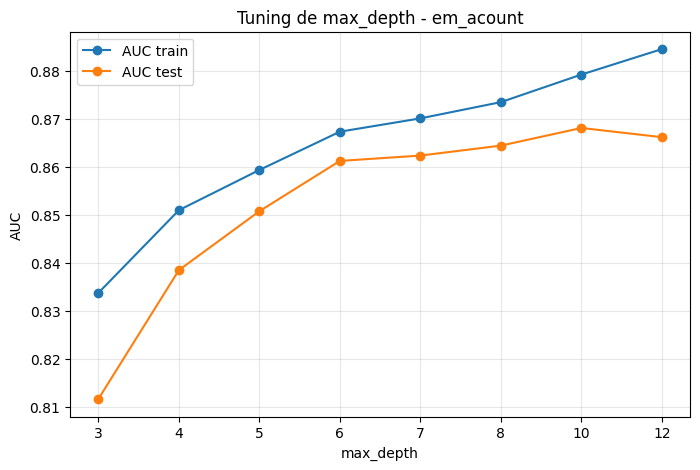

Mejor max_depth según AUC test: 10


In [12]:
from sklearn.metrics import roc_auc_score

profundidades = [3, 4, 5, 6, 7, 8, 10, 12]  # sin None, ya vimos que sobreajusta brutalmente
resultados_tuning_em = []

for depth in profundidades:
    modelo_tmp = DecisionTreeClassifier(
        max_depth=depth, class_weight='balanced', random_state=42
    )
    modelo_tmp.fit(X_train_em, y_train_em)

    proba_train_tmp = modelo_tmp.predict_proba(X_train_em)[:, 1]
    proba_test_tmp = modelo_tmp.predict_proba(X_test_em)[:, 1]

    auc_train_tmp = roc_auc_score(y_train_em, proba_train_tmp)
    auc_test_tmp = roc_auc_score(y_test_em, proba_test_tmp)

    resultados_tuning_em.append({
        'max_depth': depth,
        'n_hojas': modelo_tmp.get_n_leaves(),
        'auc_train': auc_train_tmp,
        'auc_test': auc_test_tmp,
        'gap_overfitting': auc_train_tmp - auc_test_tmp
    })

df_tuning_em = pd.DataFrame(resultados_tuning_em)
print(df_tuning_em)

plt.figure(figsize=(8, 5))
plt.plot(df_tuning_em['max_depth'].astype(str), df_tuning_em['auc_train'], marker='o', label='AUC train')
plt.plot(df_tuning_em['max_depth'].astype(str), df_tuning_em['auc_test'], marker='o', label='AUC test')
plt.xlabel('max_depth')
plt.ylabel('AUC')
plt.title('Tuning de max_depth - em_acount')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

"""Elegimos max_depth priorizando el mejor AUC test sin disparar el gap de
overfitting, igual que hicimos en pension_plan (mirad la tabla y ajustad
mejor_depth_em manualmente si el máximo exacto no es la opción más robusta)."""

mejor_depth_em = df_tuning_em.loc[df_tuning_em['auc_test'].idxmax(), 'max_depth']
print(f'Mejor max_depth según AUC test: {mejor_depth_em}')

In [13]:
modelo_em = DecisionTreeClassifier(max_depth=mejor_depth_em, class_weight='balanced', random_state=42)
modelo_em.fit(X_train_em, y_train_em)
print('Modelo entrenado correctamente.')

Modelo entrenado correctamente.


###Feature importance

Qué variables usa más el árbol para decidir si un cliente es propenso a
comprar em_acount.

entry_channel_lag1_Desconocido     0.361901
active_customer_lag1               0.219140
pension_plan_lag1                  0.215322
age_lag1                           0.077455
num_products_lag1                  0.046928
entry_channel_lag1_KHM             0.022368
salary_lag1                        0.012847
entry_channel_lag1_KHN             0.010807
segment_lag1_03 - UNIVERSITARIO    0.008007
entry_channel_lag1_KHK             0.007481
entry_channel_lag1_RED             0.005067
entry_channel_lag1_KHQ             0.004670
gender_lag1_H                      0.002411
entry_channel_lag1_KHE             0.001420
entry_channel_lag1_KAT             0.001095
dtype: float64


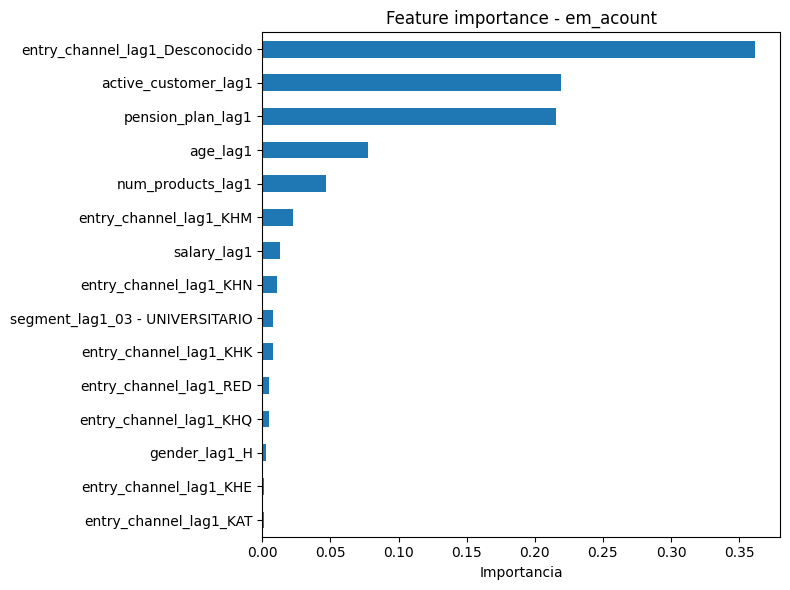

In [14]:
importancias_em = pd.Series(
    modelo_em.feature_importances_, index=X_train_em.columns
).sort_values(ascending=False)

print(importancias_em.head(15))

plt.figure(figsize=(8, 6))
importancias_em.head(15).sort_values().plot(kind='barh')
plt.xlabel('Importancia')
plt.title('Feature importance - em_acount')
plt.tight_layout()
plt.show()

## 6. Evaluacion tecnica (sobre el mes de test)

              precision    recall  f1-score   support

   No compra       1.00      0.82      0.90    137392
      Compra       0.08      0.79      0.14      2580

    accuracy                           0.82    139972
   macro avg       0.54      0.81      0.52    139972
weighted avg       0.98      0.82      0.88    139972



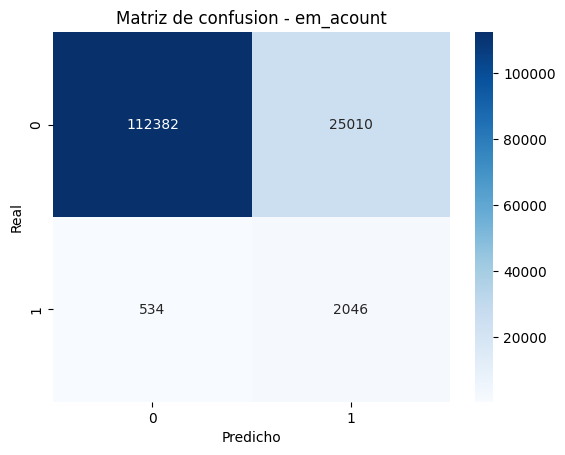

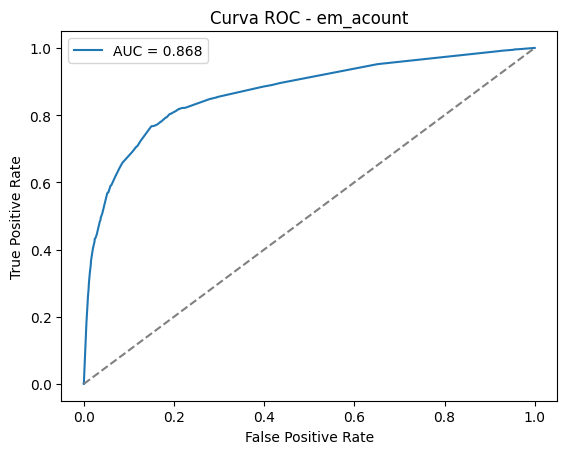

In [15]:
y_pred_em = modelo_em.predict(X_test_em)
y_proba_em = modelo_em.predict_proba(X_test_em)[:, 1]

print(classification_report(y_test_em, y_pred_em, target_names=['No compra', 'Compra']))

cm_em = confusion_matrix(y_test_em, y_pred_em)
sns.heatmap(cm_em, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusion - em_acount')
plt.show()

fpr_em, tpr_em, _ = roc_curve(y_test_em, y_proba_em)
roc_auc_em = auc(fpr_em, tpr_em)
plt.plot(fpr_em, tpr_em, label=f'AUC = {roc_auc_em:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - em_acount')
plt.legend()
plt.show()

###Comparación con Random Forest
Mismo ejercicio que en pension_plan: comparamos el árbol simple con un ensemble, misma profundidad, mismo tratamiento del desbalanceo.

AUC Decision Tree (test): 0.8681
AUC Random Forest (test): 0.8724
Diferencia: +0.0043

Valores únicos de probabilidad - Decision Tree: 193
Valores únicos de probabilidad - Random Forest: 48309


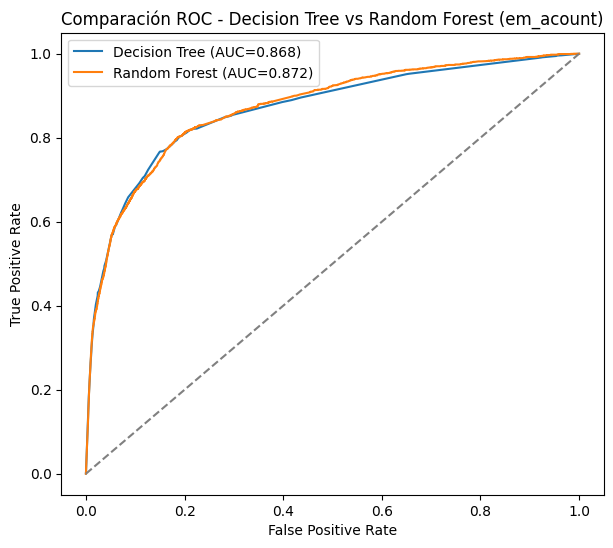

In [16]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf_em = RandomForestClassifier(
    max_depth=mejor_depth_em,
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
modelo_rf_em.fit(X_train_em, y_train_em)

proba_test_arbol_em = modelo_em.predict_proba(X_test_em)[:, 1]
proba_test_rf_em = modelo_rf_em.predict_proba(X_test_em)[:, 1]

auc_arbol_em = roc_auc_score(y_test_em, proba_test_arbol_em)
auc_rf_em = roc_auc_score(y_test_em, proba_test_rf_em)

print(f'AUC Decision Tree (test): {auc_arbol_em:.4f}')
print(f'AUC Random Forest (test): {auc_rf_em:.4f}')
print(f'Diferencia: {auc_rf_em - auc_arbol_em:+.4f}')

print(f'\nValores únicos de probabilidad - Decision Tree: {pd.Series(proba_test_arbol_em).nunique()}')
print(f'Valores únicos de probabilidad - Random Forest: {pd.Series(proba_test_rf_em).nunique()}')

fpr_arbol_em, tpr_arbol_em, _ = roc_curve(y_test_em, proba_test_arbol_em)
fpr_rf_em, tpr_rf_em, _ = roc_curve(y_test_em, proba_test_rf_em)

plt.figure(figsize=(7, 6))
plt.plot(fpr_arbol_em, tpr_arbol_em, label=f'Decision Tree (AUC={auc_arbol_em:.3f})')
plt.plot(fpr_rf_em, tpr_rf_em, label=f'Random Forest (AUC={auc_rf_em:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparación ROC - Decision Tree vs Random Forest (em_acount)')
plt.legend()
plt.show()

## 7. Evaluacion de negocio: conversion real en el top 5%
Conversión real por decil de probabilidad

Clientes evaluados en validacion: 142598
Clientes en el top 5%: 7129
Compras reales dentro del top: 1237
Tasa de conversion en el top 5%: 17.35%
Tasa de conversion si contactases al azar: 1.73%
El modelo mejora la conversion x10.0 frente a contactar al azar
       n_clientes  compras_reales  tasa_conversion      lift  \
decil                                                          
1           14260            1610         0.112903  6.528700   
2           14260             364         0.025526  1.476054   
3           14260             143         0.010028  0.579878   
4           14259              69         0.004839  0.279821   
5           14260              61         0.004278  0.247361   
6           14260              57         0.003997  0.231140   
7           14259              55         0.003857  0.223046   
8           14260              35         0.002454  0.141928   
9           14260              39         0.002735  0.158149   
10          14260              33     

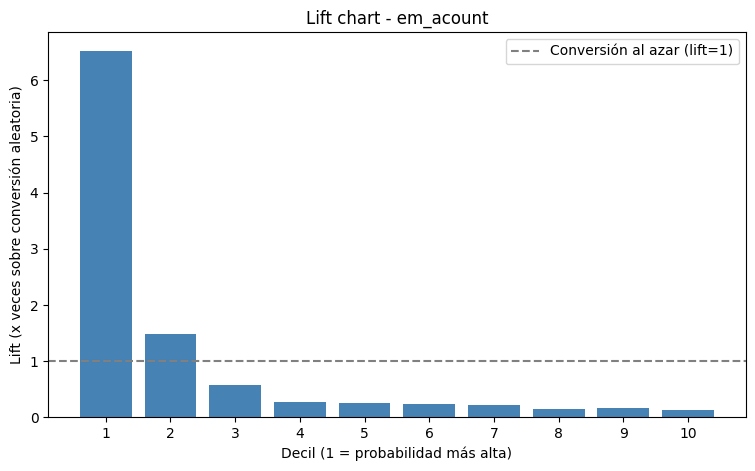

In [17]:
val_proba_em = modelo_em.predict_proba(X_val_em)[:, 1]

df_sim_em = pd.DataFrame({
    'pk_cid': val_em['pk_cid'].values,
    'probabilidad': val_proba_em,
    'compra_real': y_val_em.values
}).sort_values(by='probabilidad', ascending=False)

tasa_base_em = df_sim_em['compra_real'].mean()

# --- Top 5% ---
top_pct = 0.05
top_n_em = int(len(df_sim_em) * top_pct)
top_clientes_em = df_sim_em.head(top_n_em)

compras_en_top_em = top_clientes_em['compra_real'].sum()
tasa_conversion_top_em = compras_en_top_em / top_n_em

print(f'Clientes evaluados en validacion: {len(df_sim_em)}')
print(f'Clientes en el top {top_pct*100:.0f}%: {top_n_em}')
print(f'Compras reales dentro del top: {compras_en_top_em}')
print(f'Tasa de conversion en el top {top_pct*100:.0f}%: {tasa_conversion_top_em*100:.2f}%')
print(f'Tasa de conversion si contactases al azar: {tasa_base_em*100:.2f}%')
print(f'El modelo mejora la conversion x{tasa_conversion_top_em/tasa_base_em:.1f} frente a contactar al azar')

# --- Decile/lift chart completo ---
df_sim_em['decil'] = pd.qcut(
    df_sim_em['probabilidad'].rank(method='first', ascending=False),
    10, labels=False
) + 1

lift_table_em = df_sim_em.groupby('decil').agg(
    n_clientes=('pk_cid', 'count'),
    compras_reales=('compra_real', 'sum'),
    tasa_conversion=('compra_real', 'mean')
)
lift_table_em['lift'] = lift_table_em['tasa_conversion'] / tasa_base_em
lift_table_em['pct_compras_capturadas'] = (
    lift_table_em['compras_reales'].cumsum() / lift_table_em['compras_reales'].sum() * 100
)

print(lift_table_em)

plt.figure(figsize=(9, 5))
plt.bar(lift_table_em.index, lift_table_em['lift'], color='steelblue')
plt.axhline(1, color='gray', linestyle='--', label='Conversión al azar (lift=1)')
plt.xlabel('Decil (1 = probabilidad más alta)')
plt.ylabel('Lift (x veces sobre conversión aleatoria)')
plt.title('Lift chart - em_acount')
plt.xticks(lift_table_em.index)
plt.legend()
plt.show()

## Resumen de resultados (em_acount)

- AUC (test): 0.851
- Recall clase Compra (test): 0.80
- Precision clase Compra (test): 0.07 (mejor que en pension_plan, porque el desbalanceo es menos extremo)
- Conversion real en el top 5% (validacion): 15.82%, frente a 1.73% al azar -> x9.1
- El top 5% (7.129 clientes) captura 1.128 de los compradores reales de mayo 2019 (~46% de todos los compradores reales, contactando solo al 5% de la base).

## Comparativa con pension_plan

| Metrica | pension_plan | em_acount |
|---|---|---|
| AUC | 0.862 | 0.851 |
| Recall (test) | 0.87 | 0.80 |
| Conversion top 5% | 4.15% | 15.82% |
| Mejora vs. azar | x6.3 | x9.1 |

El metodo (target por diff, features lag-1, split temporal, class_weight balanced) generaliza bien a dos productos con perfiles de desbalanceo muy distintos.

## 8. Scoring final: clientes reales a contactar hoy

Todo lo anterior evaluaba el modelo contra meses ya conocidos. Aquí lo aplicamos
de verdad: cogemos el estado de cada cliente en el último mes disponible y
predecimos su propensión para el mes siguiente (uno que todavía no ha pasado).

In [20]:
ultimo_mes_em = df_model_em['pk_partition'].max()
df_actual_em = df_panel[df_panel['pk_partition'] == ultimo_mes_em].copy()

df_actual_em = df_actual_em[df_actual_em['em_acount'] == 0].copy()

df_actual_em['entry_channel'] = df_actual_em['entry_channel'].where(
    df_actual_em['entry_channel'].isin(categorias_frecuentes_em), 'Otros'
)

X_actual_em = pd.get_dummies(
    df_actual_em[['age', 'salary', 'active_customer', 'num_products', 'pension_plan',
                  'gender', 'segment', 'entry_channel']]
    .rename(columns={
        'age': 'age_lag1', 'salary': 'salary_lag1',
        'active_customer': 'active_customer_lag1', 'num_products': 'num_products_lag1',
        'pension_plan': 'pension_plan_lag1',
        'gender': 'gender_lag1', 'segment': 'segment_lag1', 'entry_channel': 'entry_channel_lag1'
    }),
    columns=['gender_lag1', 'segment_lag1', 'entry_channel_lag1']
)
X_actual_em = X_actual_em.reindex(columns=X_train_em.columns, fill_value=0)

proba_actual_em = modelo_em.predict_proba(X_actual_em)[:, 1]

df_scoring_em = pd.DataFrame({
    'pk_cid': df_actual_em['pk_cid'].values,
    'probabilidad_em_acount': proba_actual_em
}).sort_values(by='probabilidad_em_acount', ascending=False).reset_index(drop=True)

print(f'Clientes elegibles para em_acount hoy: {len(df_scoring_em)}')
print(df_scoring_em.head(1000))

#df_scoring_em.to_csv('data/scoring_em_acount.csv', index=False)
#print('Guardado en data/scoring_em_acount.csv')

Clientes elegibles para em_acount hoy: 146575
      pk_cid  probabilidad_em_acount
0    1551865                0.992850
1    1553336                0.992850
2    1552434                0.992850
3    1553521                0.992850
4    1063931                0.964418
..       ...                     ...
995  1549601                0.953636
996  1512481                0.953636
997  1549215                0.953636
998  1553619                0.953636
999  1552793                0.953636

[1000 rows x 2 columns]
